# Les trois moments de quantification — galerie (Sprint 46)

Comparaison **frontale** de *quand* et *comment* on quantifie, à modèle / données / seed fixés :

- **`before` (QAT)** — fake-quant *dans* la boucle d'entraînement (straight-through). Évalué **avec** fake-quant à l'inférence → **borne haute** (la carte n'exécute jamais de fake-quant).
- **`after` (PTQ)** — quantification des poids d'un modèle FP32 déjà entraîné.
- **`both` (QAT → export PTQ)** — entraîner à fake-quant puis exporter à travers le noyau PTQ calibré. **C'est le chemin réel vers la carte** (noyau entier), donc la seule colonne *fidèle au déploiement*.

Message : *quantifier ≠ quantifier* — le **moment** et la **calibration** dominent. Toutes les valeurs sont chargées depuis les JSON `experiments/exp_S46_*` (0 chiffre en dur). Plateforme : **PC / émulateur bit-exact** ; board différée (S4608).


In [1]:
import json
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.figures import registry  # noqa: E402
import src.figures.catalogs  # noqa: E402,F401  — auto-enregistrement
from src.figures.style import apply_style  # noqa: E402
from src.utils.reproducibility import set_seed  # noqa: E402

FIG_ROOT = ROOT / "docs/figures/quantization_moment"
EXP = ROOT / "experiments"

# (Re)génère les 4 figures de façon idempotente (seed fixé).
set_seed(42)
apply_style("slide")
paths = registry.get_catalog("quantization/moment")(ROOT / "docs/figures")
print(f"{len(paths)} figure(s) générée(s) sous {FIG_ROOT}")


def load_json(rel):
    p = EXP / rel
    if not p.exists():
        return None
    with open(p, encoding="utf-8") as f:
        return json.load(f)


def show_fig(name, caption=""):
    fig = FIG_ROOT / name
    if fig.exists():
        display(Image(str(fig)))
    if caption:
        display(Markdown(caption))


✅ Seed fixé à 42
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_moment/M1_moments_bars.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_moment/M2_moment_heatmap.png
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_moment/M3_calibration_effect.png


[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_moment/M4_hdc_maha_context.png
4 figure(s) générée(s) sous /home/leonard/Documents/ENAC/cl-embedded/docs/figures/quantization_moment


## M1 — Les quatre moments par (modèle × dataset)

EWC et TinyOL sont les deux modèles à **vraie boucle de fake-quant** → l'axe `before / after / both` a un sens. Les résumés ci-dessous sont lus depuis les JSON.


**EWC × Monitoring** — fp32 = `0.97464` · before = `0.974477` · after = `0.974649` · both = `0.974663` (Δboth vs fp32 = `2.3e-05`, Gap 3 métrique = `True`)

**EWC × Pronostia** — fp32 = `0.998703` · before = `0.997811` · after = `0.997767` · both = `0.997787` (Δboth vs fp32 = `-0.000916`, Gap 3 métrique = `True`)

**TINYOL × Monitoring** — fp32 = `0.877093` · before = `0.692286` · after = `0.692286` · both = `0.692286` (Δboth vs fp32 = `-0.184807`, Gap 3 métrique = `False`)

**TINYOL × Pronostia** — fp32 = `0.665434` · before = `0.65937` · after = `0.65937` · both = `0.65937` (Δboth vs fp32 = `-0.006064`, Gap 3 métrique = `True`)

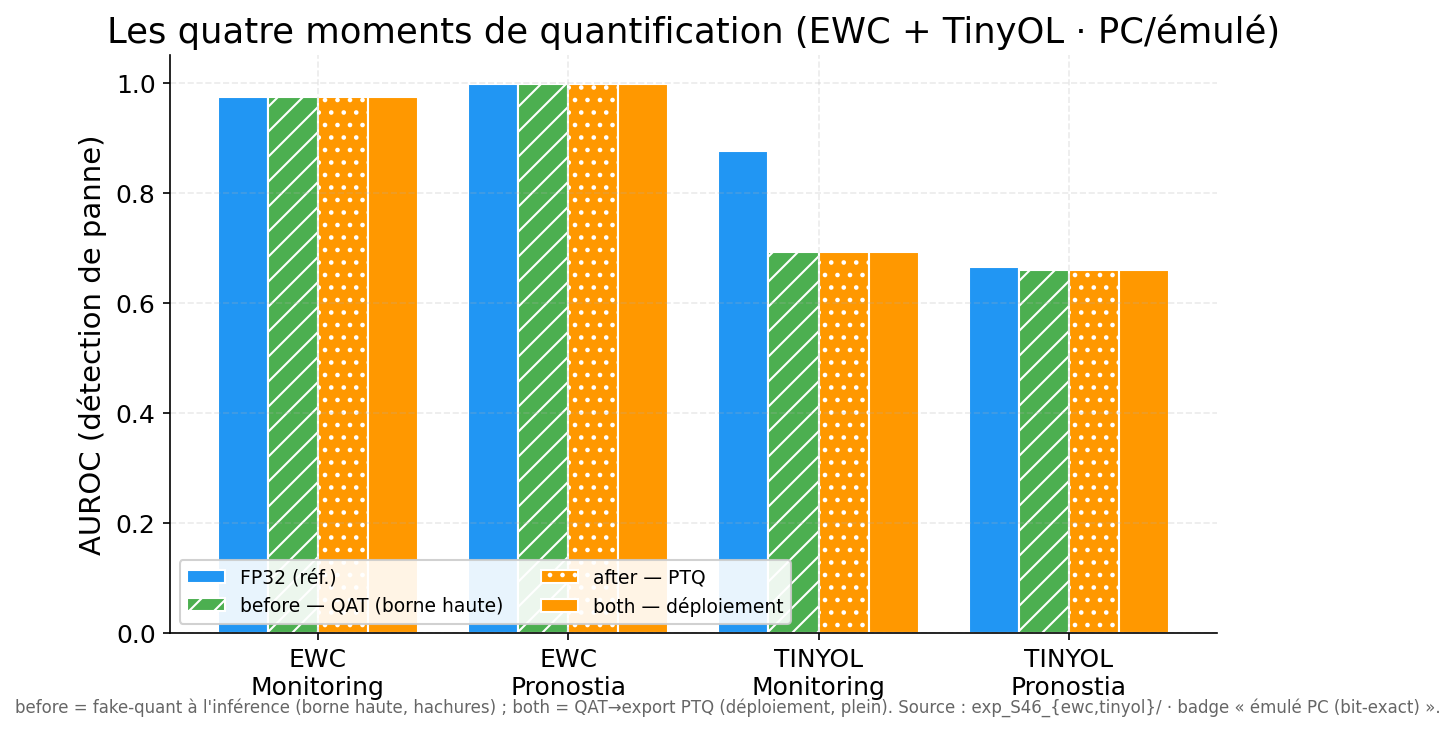

In [2]:
for model in ("ewc", "tinyol"):
    for ds in ("monitoring", "pronostia"):
        d = load_json(f"exp_S46_{model}/{ds}_all.json")
        if d is None:
            display(Markdown(f"> ⚠️ `exp_S46_{model}/{ds}_all.json` absent."))
            continue
        m = d["moments"]
        display(Markdown(
            f"**{model.upper()} × {ds.capitalize()}** — "
            f"fp32 = `{m['fp32']['metric']}` · before = `{m['before']['metric']}` · "
            f"after = `{m['after']['metric']}` · both = `{m['both']['metric']}` "
            f"(Δboth vs fp32 = `{d['delta_both_vs_fp32']}`, Gap 3 métrique = `{d['gap3_metric_ok_both']}`)"
        ))
show_fig("M1_moments_bars.png")


## M2 — Heatmap métrique = f(moment, modèle × dataset)

Les colonnes **HDC** et **Mahalanobis** apparaissent en **gris N/A** : ces modèles ne sont pas sur l'axe des moments (cf. M4). Aucune cellule 3-way n'est fabriquée pour eux.


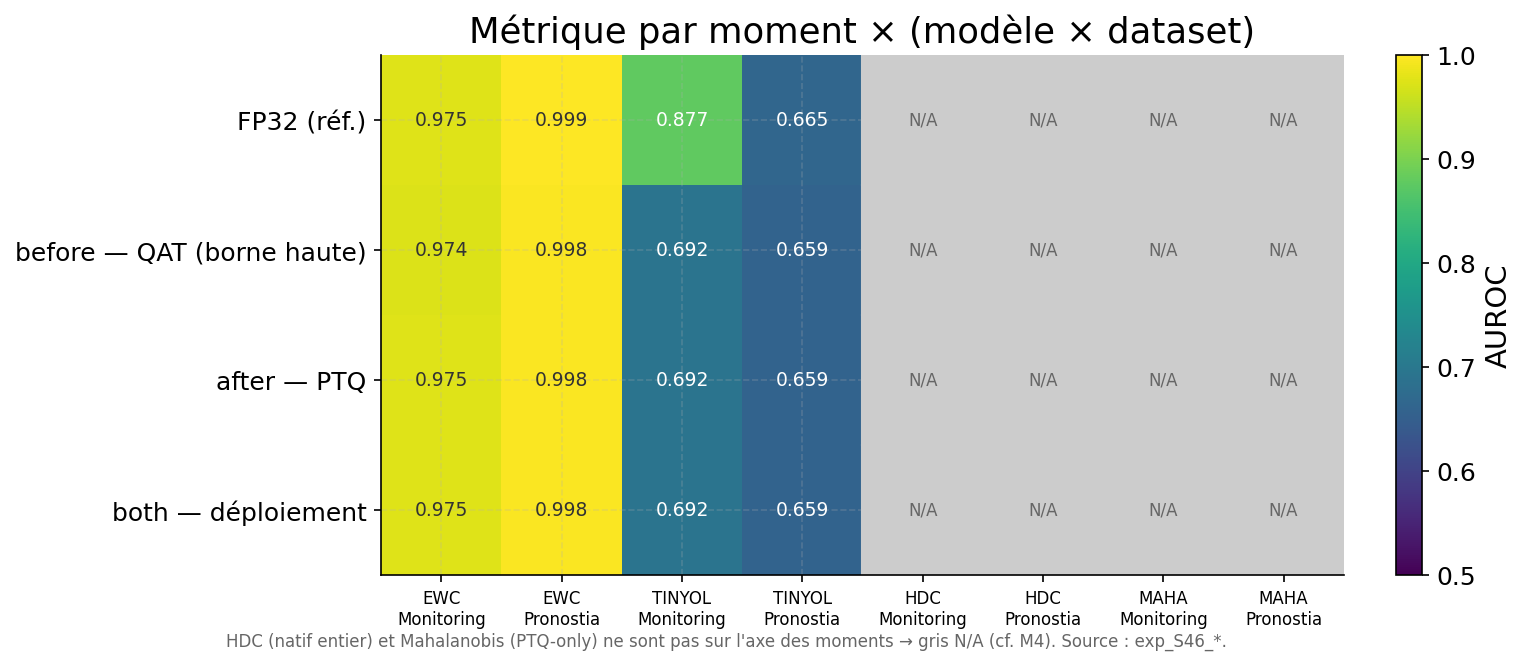

In [3]:
show_fig("M2_moment_heatmap.png")


## M3 — Effet de la calibration (lien ablation S39)

Balayage `after_scheme` sur les colonnes `after` / `both` d'EWC : **legacy C (1/128 figé) → per-tensor calibré → per-canal INT8**. Isole l'effet **calibration** du scale.


**EWC × Monitoring** — after : legacy `0.497523` → per-tensor `0.974649` → per-canal `0.974878`

**EWC × Pronostia** — after : legacy `0.545804` → per-tensor `0.997767` → per-canal `0.997787`

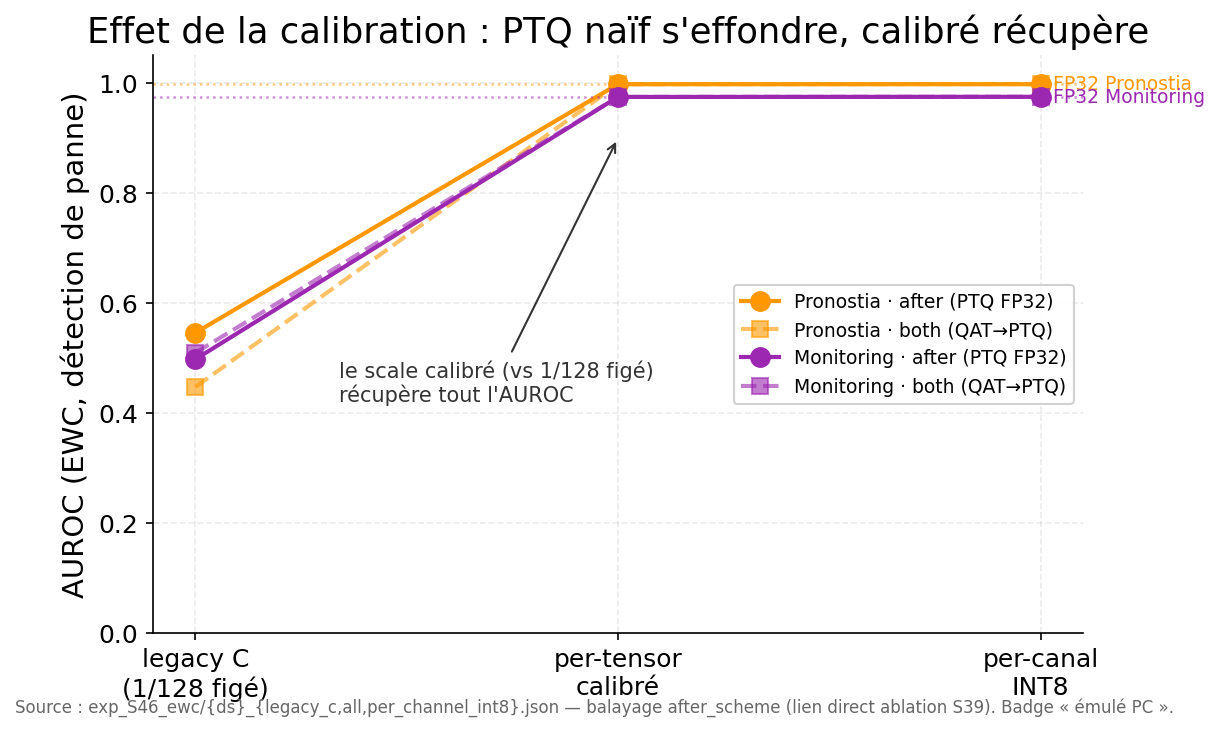

In [4]:
for ds in ("monitoring", "pronostia"):
    legacy = load_json(f"exp_S46_ewc/{ds}_legacy_c.json")
    calib = load_json(f"exp_S46_ewc/{ds}_all.json")
    perch = load_json(f"exp_S46_ewc/{ds}_per_channel_int8.json")
    if not all((legacy, calib, perch)):
        continue
    display(Markdown(
        f"**EWC × {ds.capitalize()}** — after : legacy `{legacy['moments']['after']['metric']}` "
        f"→ per-tensor `{calib['moments']['after']['metric']}` "
        f"→ per-canal `{perch['moments']['after']['metric']}`"
    ))
show_fig("M3_calibration_effect.png")


## M4 — Contexte hors-axe : HDC & Mahalanobis

- **HDC** est *nativement entier* (hypervecteurs int8 ±1, mémoire associative int16) : la quantification est **structurelle**, métrique INT8 ≡ FP32 par construction — pas de moment avant/après.
- **Mahalanobis** est **PTQ-only** (fit statistique, aucun entraînement gradient) : son axe pertinent est le **format** de Σ⁻¹ — `int8` casse sur grande dynamique, `q15` récupère (Sprint 34).


**HDC × Monitoring** — INT8 natif = `0.744295` (≡ FP32 hypothétique) · RAM ×`2.3316` · _HDC natif entier (hypervecteurs int8 ±1, mémoire associative int16) : quantification structurelle, pas de moment avant/après._

**Maha × Monitoring** — fp32 = `0.972501` · int8 = `0.972557` (Δ `5.6e-05`) · q15 = `0.972501` (Δ `0.0`)

**HDC × Pronostia** — INT8 natif = `0.723091` (≡ FP32 hypothétique) · RAM ×`2.3316` · _HDC natif entier (hypervecteurs int8 ±1, mémoire associative int16) : quantification structurelle, pas de moment avant/après._

**Maha × Pronostia** — fp32 = `0.860259` · int8 = `0.74692` (Δ `-0.113339`) · q15 = `0.87291` (Δ `0.012651`)

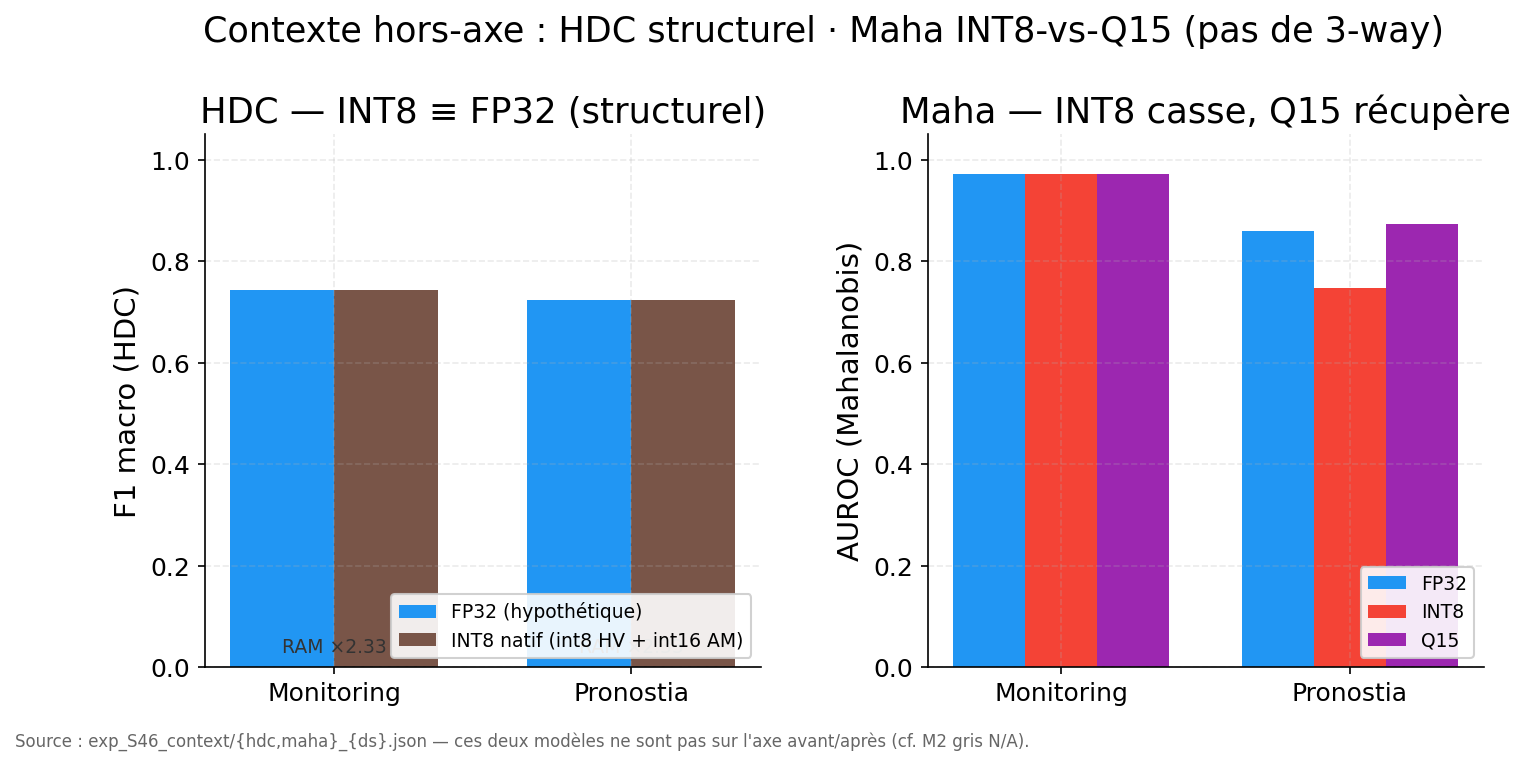

In [5]:
for ds in ("monitoring", "pronostia"):
    h = load_json(f"exp_S46_context/hdc_{ds}.json")
    if h:
        display(Markdown(
            f"**HDC × {ds.capitalize()}** — INT8 natif = `{h['values']['int8_native']}` "
            f"(≡ FP32 hypothétique) · RAM ×`{h['ram_ratio']}` · _{h['na_reason']}_"
        ))
    m = load_json(f"exp_S46_context/maha_{ds}.json")
    if m:
        display(Markdown(
            f"**Maha × {ds.capitalize()}** — fp32 = `{m['values']['fp32']}` · "
            f"int8 = `{m['values']['int8']}` (Δ `{m['delta_int8']}`) · "
            f"q15 = `{m['values']['q15']}` (Δ `{m['delta_q15']}`)"
        ))
show_fig("M4_hdc_maha_context.png")


## Lecture

- **`before` (QAT) = borne haute** : le fake-quant à l'inférence préserve la métrique, mais la carte ne l'exécute jamais tel quel.
- **PTQ naïf (`after` = legacy C, 1/128 figé) s'effondre** : AUROC → quasi-aléatoire (cf. M3).
- **PTQ calibré (`after` = per-tensor / per-canal) récupère** tout l'AUROC → c'est la *calibration du scale*, pas le format, qui compte.
- **`both` (QAT → export PTQ calibré) = déploiement** : métrique préservée (Gap 3 métrique ✅) + RAM des poids ÷4 (Gap 3 RAM ✅).

## Limites (honnêteté)

- **HDC / Mahalanobis hors-axe** : gris N/A dans M2 ; leur contexte est en M4 (structurel / format), pas une grille 3-way.
- **TinyOL** : pas de noyau entier per-canal ni de vraie boucle QAT sur l'autoencodeur → sur l'erreur de reconstruction `before ≈ after ≈ both` (collapse **documenté** dans `na_note`, pas masqué).
- **Board différée (S4608)** : toutes les cellules ici sont **PC / émulées** ; aucun chiffre board inventé.
